# 03. Pytorch Computer Vision

Computer vision is the art of teaching a computer to see.

For example, it could involve building a model to classify whether a photo is of a cat or a dog (binary classification).

Or whether a photo is of a cat, dog or chicken (multi-class classification).

Or identifying where a car appears in a video frame (object detection).

Or figuring out where different objects in an image can be separated (panoptic segmentation).

## What we are going to cover 

* Get a vision dataset using torchvision.datasets
* Architecture of a convolutional neural network (CNN) with PyTorch
* An end-to-end multi-class image classification problem
* Steps in modeling with CNNs in Pytorch
    * Creating a CNN model with PyTorch 
    * Picking a loss and optimizer 
    * Training a model 
    * Evaluating a model

## Computer Vision Inputs and Outputs

A image is typically in the RBG (Red, Green, Blue) space. This suggests an image will have three channels where one is for values of Red, one is for values of Green, and one is for values of Blue.  

To prepare images for Computer Vision: 
1. Represent the image as numbers (Image as a Tensor) (Normalize the pixel values)
2. Pass the images into an algorithmn (Typically a CNN)
3. Prediction classification for the images

Normalization: 
[batch_size, width, height, color_channels] gets represented as a tensor

Ex: 
* Shape: [32, 224, 224, 3] Color channels last

(224, 224) is a common start point for normalization of image sizes. 


Grayscale Images:

Same idea as RGB space images however the number of channels is simply 1

Ex: 
* Shape = [None, 28, 28, 1] format: (NHWC) Color channels last 
* Shape = [None, 1, 28, 28] format: (NCHW) Color channels first

## Typical Architecture of a CNN

| Hyperparameter/Layer Type               | What does it do?                                                  |                                                                       |
|-----------------------------------------|-------------------------------------------------------------------|-----------------------------------------------------------------------|
| Input Image(s)                          | Target images you'd like to discover patterns in                  | Whatever you can take a photo or video of                             |
| Input Layer                             | Takes in target images and pre-processes them for further layers  | input_shape = [batch_size, image_height, image_width, color_channels] |
| Convolutional Layer                     | Extracts/learns the most important features from target images    | Multiple, can create with torch.nn.ConvXd()                           |
| Hidden activation/non-linear activation | Adds non-linearity to learned features                            | Usually ReLU                                                          |
| Pooling Layer                           | Reduces the dimensionality of leaned image features               | Max (torch.nn.MaxPool2d()) or Average                                 |
| Output layer/linear layer               | Takes learned features and outputs them in shape of target labels | torch.nn.Linear()                                                     |
| Output activation                       | Converts output logits to predication probabilities               | torch.sigmoid() or torch.softmax()                                    |

## Common Libraries for Computer Vision

* `torchvision`: Contains datasets, model architectures and image transformations often used for computer vision problems
* `torchvision.datasets`: Find examples computer vision datasets for different applications and also conatins a series of base classes for making custom datasets
* `torchvision.models`: Module contains computer vision model architectures which you can use for your own problems
* `torchvision.transforms`: Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here
* `torch.utils.data.Dataset`: Base dataset class for PyTorch
* `torch.utils.data.DataLoader`: Creates a Python iterable over a dataset (created with torch.utils.data.Dataset)

In [124]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision 
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 1.10.0
torchvision version: 0.11.1


## 1. Getting a Dataset (FashionMNIST)

contains grayscale images of 10 different kinds of clothing

In [125]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

In [126]:
# See first training sample
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

#### 1.1 Input and output shapes of a computer vision model

We've got a big tensor of values (the image) leading to a single value for the target (the label).

In [127]:
# What's the shape of the image?
image.shape

torch.Size([1, 28, 28])

Shape is suggesting `[color_channels=1, height=28, width=28]`. SInce we have one channel this measn the images are grayscale.

PyTorch generally accepts NCHW (channels first) as the default for many operators.

However, PyTorch also explains that NHWC (channels last) performs better and is considered best practice.

For now, since our dataset and models are relatively small, this won't make too much of a difference.

But keep it in mind for when you're working on larger image datasets and using convolutional neural networks (we'll see these later).

In [128]:
# How many samples are there? 
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

So we've got 60,000 training samples and 10,000 testing samples.

What classes are there?

We can find these via the .classes attribute.

In [129]:
# See classes 
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

It looks like we're dealing with 10 different kinds of clothes.

Because we're working with 10 different classes, it means our problem is multi-class classification.

Let's get visual.

#### 1.2 Visualing our data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

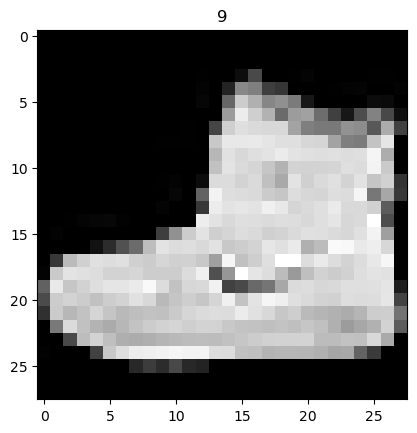

In [130]:
import matplotlib.pyplot as plt
# Plot one example image 
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze(), cmap="gray")
plt.title(label)

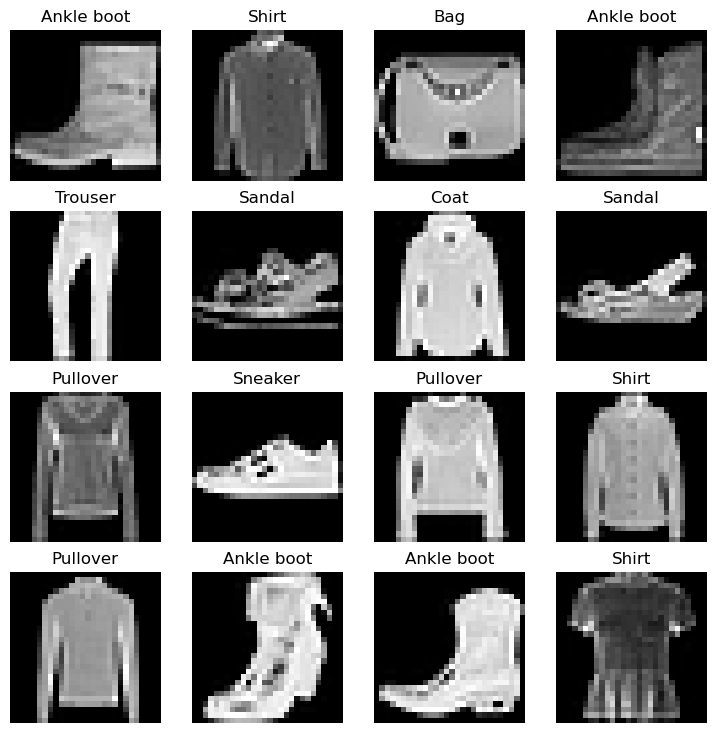

In [131]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

this dataset doesn't look too aesthetic.

But the principles we're going to learn on how to build a model for it will be similar across a wide range of computer vision problems.

In essence, taking pixel values and building a model to find patterns in them to use on future pixel values.

Plus, even for this small dataset (yes, even 60,000 images in deep learning is considered quite small), could you write a program to classify each one of them?

You probably could.

But I think coding a model in PyTorch would be faster.

#### 2. Prepare DataLoader

The DataLoader does what you think it might do.

It helps load data into a model.

For training and for inference.

It turns a large Dataset into a Python iterable of smaller chunks.

These smaller chunks are called batches or mini-batches and can be set by the batch_size parameter.

Why do this?

Because it's more computationally efficient.

In an ideal world you could do the forward pass and backward pass across all of your data at once.

But once you start using really large datasets, unless you've got infinite computing power, it's easier to break them up into batches.

It also gives your model more opportunities to improve.

With mini-batches (small portions of the data), gradient descent is performed more often per epoch (once per mini-batch rather than once per epoch).

What's a good batch size?

32 is a good place to start for a fair amount of problems.

But since this is a value you can set (a hyperparameter) you can try all different kinds of values, though generally powers of 2 are used most often (e.g. 32, 64, 128, 256, 512).

In [132]:
from torch.utils.data import DataLoader

# Setup batch size
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(
    train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch?
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(
    test_data, 
    batch_size=BATCH_SIZE,
    shuffle=False # You don't have to shuffle testing data
)

# Check out what has been created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000015CE3D60A60>, <torch.utils.data.dataloader.DataLoader object at 0x0000015CB1F4B370>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [133]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


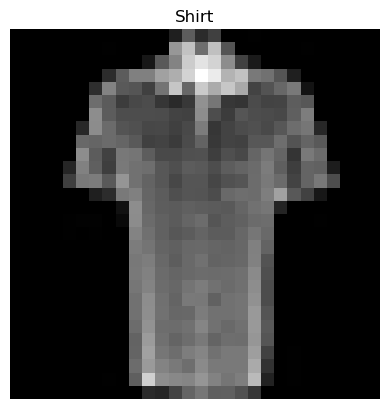

In [134]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

### 3. Model 0: Build a Baseline model

Time to build a baseline model by subclassing nn.Module.

A baseline model is one of the simplest models you can imagine.

You use the baseline as a starting point and try to improve upon it with subsequent, more complicated models.

Our baseline will consist of two nn.Linear() layers.

We've done this in a previous section but there's going to be one slight difference.

Because we're working with image data, we're going to use a different layer to start things off.

And that's the nn.Flatten() layer.

nn.Flatten() compresses the dimensions of a tensor into a single vector.

This is easier to understand when you see it.

In [135]:
# Create a Flatten Layer 
flatten_model = nn.Flatten() 

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x)

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# Try uncommenting below and see what happens
print(x)
print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 

The nn.Flatten() layer took our shape from [color_channels, height, width] to [color_channels, height*width].

Why do this?

Because we've now turned our pixel data from height and width dimensions into one long feature vector.

And nn.Linear() layers like their inputs to be in the form of feature vectors.

Let's create our first model using nn.Flatten() as the first layer.

In [136]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

We've got a baseline model class we can use, now let's instantiate a model.

We'll need to set the following parameters:

* input_shape=784 - this is how many features you've got going in the model, in our case, it's one for every pixel in the target image (28 pixels high by 28 pixels wide = 784 features).
* hidden_units=10 - number of units/neurons in the hidden layer(s), this number could be whatever you want but to keep the model small we'll start with 10.
* output_shape=len(class_names) - since we're working with a multi-class classification problem, we need an output neuron per class in our dataset.

Let's create an instance of our model and send to the CPU for now (we'll run a small test for running model_0 on CPU vs. a similar model on GPU soon).

In [137]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # one for every pixel (28x28)
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
)
model_0.to("cpu") # keep model on CPU to begin with

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

#### 3.1 Setup loss, optimizer and evaluation metrics

Since we're working on a classification problem, let's bring in our helper_functions.py script and subsequently the accuracy_fn() we defined in notebook 02.

In [138]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [139]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

#### 3.2 Creating a function to time our expirements 

Loss function and optimizer ready!

It's time to start training a model.

But how about we do a little experiment while we train.

I mean, let's make a timing function to measure the time it takes our model to train on CPU versus using a GPU.

We'll train this model on the CPU but the next one on the GPU and see what happens.

Our timing function will import the timeit.default_timer() function from the Python timeit module

In [140]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

#### 3.3 Creating a training loop and training a model on batches of data

create a training loop and a testing loop to train and evaluate our model.

We'll be using the same steps as the previous notebook(s), though since our data is now in batch form, we'll add another loop to loop through our data batches.

Our data batches are contained within our DataLoaders, train_dataloader and test_dataloader for the training and test data splits respectively.

A batch is BATCH_SIZE samples of X (features) and y (labels), since we're using BATCH_SIZE=32, our batches have 32 samples of images and targets.

And since we're computing on batches of data, our loss and evaluation metrics will be calculated per batch rather than across the whole dataset.

This means we'll have to divide our loss and accuracy values by the number of batches in each dataset's respective dataloader.

Let's step through it:

Loop through epochs.
Loop through training batches, perform training steps, calculate the train loss per batch.
Loop through testing batches, perform testing steps, calculate the test loss per batch.
Print out what's happening.
Time it all (for fun).



In [141]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (Small for faster training times)
epochs = 3 

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    ### Training 
    # Instantiate Train loss as 0 
    train_loss = 0

    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        # 1. put model in training mode
        model_0.train() 

        # 2. Forward pass
        y_pred = model_0(X)

        # 3. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() # accumulatively add up the loss per epoch, remember that we are passing in batches of data, so we need to add up the loss per batch to get the total loss per epoch

        # 4. Optimizer zero grad
        optimizer.zero_grad()

        # 5. Loss backward
        loss.backward()

        # 6. Optimizer step
        optimizer.step() # Optimizing in batches is more efficient rather than optimizing once the model has seen all the data/batches. 

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    
    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader) # we want to see the average loss per batch per epoch, not the total loss per epoch (which is what we get by accumulatively adding up the loss per batch)

    ### Testing 
    # Setup variables for accumulatively adding up loss and accuracy 
    test_loss, test_acc = 0, 0 
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)
           
            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        
        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time      
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:05<00:11,  5.61s/it]


Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [00:11<00:05,  5.57s/it]


Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [00:16<00:00,  5.56s/it]


Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 16.679 seconds


In [142]:
str(next(model_0.parameters()).device)

'cpu'

In [143]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4766390025615692,
 'model_acc': 83.42651757188499}

We can use this dictionary to compare the baseline model results to other models later on.

### 5. Setup device agnostic-code (for using a GPU) 

In [144]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 6. Model 1: Building a better model with non-linearity
Seeing the data we've been working with, do you think it needs non-linear functions?

And remember, linear means straight and non-linear means non-straight.

Let's find out.

We'll do so by recreating a similar model to before, except this time we'll put non-linear functions (nn.ReLU()) in between each linear layer.

In [145]:
# Create model with non-linear and linear layers 
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # Flatten input image to a single vector of pixels (28x28 -> 784)
            nn.Linear(in_features=input_shape, out_features=hidden_units), # hidden layer with non-linear activation function
            nn.ReLU(), # non-linear activation function
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU() 
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)

Now let's instantiate it with the same settings we used before.

We'll need input_shape=784 (equal to the number of features of our image data), hidden_units=10 (starting small and the same as our baseline model) and output_shape=len(class_names) (one output unit per class).

In [146]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, # number of input features
    hidden_units=10,
    output_shape=len(class_names) # number of output classes desired
).to(device) # send model to GPU if it's available
next(model_1.parameters()).device # check model device

device(type='cuda', index=0)

#### 6.1 Setup loss, optimizer and evaluation metrics

As usual, we'll setup a loss function, an optimizer and an evaluation metric (we could do multiple evaluation metrics but we'll stick with accuracy for now).

In [147]:
from torchmetrics.classification import MulticlassAccuracy


# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

# Define accuracy metric
acc_fn = MulticlassAccuracy(num_classes=len(class_names)).to(device)

So far we've been writing train and test loops over and over.

Let's write them again but this time we'll put them in functions so they can be called again and again.

And because we're using device-agnostic code now, we'll be sure to call .to(device) on our feature (X) and target (y) tensors.

For the training loop we'll create a function called train_step() which takes in a model, a DataLoader a loss function and an optimizer.

The testing loop will be similar but it'll be called test_step() and it'll take in a model, a DataLoader, a loss function and an evaluation function.

In [148]:
from torchmetrics.classification import MulticlassAccuracy

def train_step(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader, 
        loss_fn: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        acc_fn: MulticlassAccuracy,
        device: torch.device = device
):
    """
    
    """
    # Instantiate train loss and train acc 
    train_loss, train_acc = 0, 0

    # Send model to device
    model.to(device)

    # Loop through data loader batches and train model on each batch
    for batch, (X, y) in enumerate(data_loader):
        # Send data to device 
        X, y = X.to(device), y.to(device)

        # 1. Put model in training mode
        model.train()

        # 2. Forward pass
        y_pred = model(X)

        # 3. Calculate the loss 
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per batch per epoch
        train_acc += acc_fn(y_pred.argmax(dim=1), y) # accumulatively add up the accuracy per batch per epoch

        # 4. Optimizer zero grad
        optimizer.zero_grad()

        # 5. Backpropagate the loss
        loss.backward()

        # 6. Optimizer step 
        optimizer.step()
    
    # Calculate the average loss and accuracy per batch per epoch
    train_loss /= len(data_loader)
    train_acc = acc_fn.compute() # Since we have a Torch metric instance for accuracy, we need to use the .compute() 
    acc_fn.reset() # need to reset acc_fn between epochs otherwise it will keep accumulating accuracy values across epochs

    print(f"Train loss: {train_loss:.5f}, Train acc: {train_acc:.2f}%")

def test_step(
        model: torch.nn.Module,
        data_loader: torch.utils.data.DataLoader, 
        loss_fn: torch.nn.Module,
        acc_fn: MulticlassAccuracy,
        device: torch.device = device
):
    """
    
    """
    # Instantiate test loss and test acc 
    test_loss, test_acc = 0, 0

    # Send model to device
    model.to(device)

    # Put model in evaluation mode
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to device 
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate the loss and accuracy
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per batch
            test_acc += acc_fn(test_pred.argmax(dim=1), y) # accumulatively add up the accuracy per batch
        
        # adjust metrics and print out results
        test_loss /= len(data_loader)
        test_acc = acc_fn.compute()
        acc_fn.reset()        
        
        print(f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

In [149]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_1, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        acc_fn=acc_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        acc_fn=acc_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.07721, Train acc: 0.62%


 33%|███▎      | 1/3 [00:10<00:21, 10.97s/it]

Test loss: 0.94282, Test acc: 0.66%
Epoch: 1
---------
Train loss: 0.91956, Train acc: 0.66%


 67%|██████▋   | 2/3 [00:22<00:11, 11.33s/it]

Test loss: 0.90445, Test acc: 0.66%
Epoch: 2
---------
Train loss: 0.88206, Train acc: 0.67%


100%|██████████| 3/3 [00:34<00:00, 11.36s/it]

Test loss: 0.88696, Test acc: 0.66%
Train time on cuda: 34.076 seconds


Excellent!

Our model trained but the training time took longer?

Note: The training time on CUDA vs CPU will depend largely on the quality of the CPU/GPU you're using. Read on for a more explained answer.

Question: "I used a GPU but my model didn't train faster, why might that be?"

Answer: Well, one reason could be because your dataset and model are both so small (like the dataset and model we're working with) the benefits of using a GPU are outweighed by the time it actually takes to transfer the data there.

There's a small bottleneck between copying data from the CPU memory (default) to the GPU memory.

So for smaller models and datasets, the CPU might actually be the optimal place to compute on.

But for larger datasets and models, the speed of computing the GPU can offer usually far outweighs the cost of getting the data there.

However, this is largely dependent on the hardware you're using. With practice, you will get used to where the best place to train your models is.

Let's evaluate our trained model_1 using our eval_model() function and see how it went.

In [150]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn, 
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss = 0
    model.to(device)
    model.eval()

    acc_fn.to(device)
    acc_fn.reset() 

    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc_fn.update(y_pred.argmax(dim=1), y)
        
        # Scale loss and acc
        loss /= len(data_loader)
        acc = acc_fn.compute().item() # Since we have a Torch metric instance for accuracy, we need to use the .compute() and .item() to get the value out of the tensor
        acc_fn.reset()

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code 
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.8869558572769165,
 'model_acc': 0.6646000146865845}

In [151]:
# Check baseline results
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4766390025615692,
 'model_acc': 83.42651757188499}

### 7. Model 2: Building a Convolutional Neural Network

CNN's are known for their capabilities to find patterns in visual data.

And since we're dealing with visual data, let's see if using a CNN model can improve upon our baseline.

The CNN model we're going to be using is known as TinyVGG from the CNN Explainer website.

It follows the typical structure of a convolutional neural network:

`Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer`

Where the contents of [Convolutional layer -> activation layer -> pooling layer] can be upscaled and repeated multiple times, depending on requirements.

In [152]:
# Create a Convolutional Neural Network (CNN) model
class FashionMNISTModelV2(nn.Module): 
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Define the first block 
        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape, 
                out_channels=hidden_units, 
                kernel_size=3, # how big is the square that's going over the image?
                stride=1, 
                padding=1
            ),# Values we can set ourselves in NN's are called hyperparameters
            nn.ReLU(), 
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3, 
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units, 
                out_channels=hidden_units, 
                kernel_size=3, 
                stride=1, 
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3, 
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units*0, # It can be tricky defining this so instead a trick is to print the shapes in the forward pass
                                            # since for now our linear is * 0 it should show the Flatten layer shape
                out_features=output_shape
            )
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        print(f"Output shape of Conv Block 1: {x.shape}")
        x = self.block_2(x)
        print(f"Output shape of Conv Block 2: {x.shape}")
        x = self.classifier(x)
        print(f"Output shape of Classifier: {x.shape}")
        return x

In [153]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
model_2

c:\Users\delga\anaconda3\envs\ztm-pytorch-course\lib\site-packages\torch\nn\init.py:388: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=0, out_features=10, bias=True)
  )
)

#### 7.1 Stepping through nn.Conv2d()

To test the layers out, let's create some toy data just like the data used on CNN Explainer.

Question: What does the "2d" in nn.Conv2d() stand for?

The 2d is for 2-dimensional data. As in, our images have two dimensions: height and width. Yes, there's color channel dimension but each of the color channel dimensions have two dimensions too: height and width.

For other dimensional data (such as 1D for text or 3D for 3D objects) there's also nn.Conv1d() and nn.Conv3d().

In [154]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

In [155]:
test_image.shape

torch.Size([3, 64, 64])

In [156]:
# Create a single conv2d layer
conv_layer = nn.Conv2d(
    in_channels=3, 
    out_channels=10,
    kernel_size=3, # Same as the tuple (3, 3)
    stride=1,
    padding=0
)

# Conv layer expects (batch, num_channels, height, width)
# Add an extra dimension to our image which right now is [3, 64, 64]
# Adding an extra dimension will be [1, 3, 64, 64]
print(f"Test Image Shape: {test_image.shape}")

# pass the data through the convolutional layer
conv_output = conv_layer(test_image.unsqueeze(dim=0))
print(f"Test Image Shape after Conv2d layer: {conv_output.shape}")
conv_output

Test Image Shape: torch.Size([3, 64, 64])
Test Image Shape after Conv2d layer: torch.Size([1, 10, 62, 62])


tensor([[[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
            6.6224e-01, -2.3216e-01],
          [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
           -1.8551e-01, -5.7622e-01],
          [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
            1.4923e-01,  1.4236e-01],
          ...,
          [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
            4.2594e-01, -4.8341e-01],
          [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
           -3.6626e-01,  3.5645e-01],
          [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
           -4.9680e-01, -7.2258e-01]],

         [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
           -1.7643e+00,  2.5263e-01],
          [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
            4.8068e-01,  8.4869e-01],
          [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
            2.4611e-01,  6.6233e-01],
          ...,
     

Behind the scenes, our nn.Conv2d() is compressing the information stored in the image.

It does this by performing operations on the input (our test image) against its internal parameters.

The goal of this is similar to all of the other neural networks we've been building.

Data goes in and the layers try to update their internal parameters (patterns) to lower the loss function thanks to some help of the optimizer.

The only difference is how the different layers calculate their parameter updates or in PyTorch terms, the operation present in the layer forward() method.

Question: What should we set the parameters of our nn.Conv2d() layers?

That's a good one. But similar to many other things in machine learning, the values of these aren't set in stone (and recall, because these values are ones we can set ourselves, they're referred to as "hyperparameters").

The best way to find out is to try out different values and see how they effect your model's performance.

Or even better, find a working example on a problem similar to yours (like we've done with TinyVGG) and copy it.

#### 7.2 Stepping through nn.MaxPool2d()

In [157]:
# Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPoo2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through the conv_layer 
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


Notice the change in the shapes of what's happening in and out of a nn.MaxPool2d() layer.

The kernel_size of the nn.MaxPool2d() layer will affect the size of the output shape.

In our case, the shape halves from a 62x62 image to 31x31 image.

Let's see this work with a smaller tensor.

In [158]:
torch.manual_seed(42)
# Create a random tensor with a similar number of dimensions to our images
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2) # see what happens when you change the kernel_size value 

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- this is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
tensor([[[[0.3367]]]]) <- this is the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 1, 1, 1])


Notice the final two dimensions between random_tensor and max_pool_tensor, they go from [2, 2] to [1, 1].

In essence, they get halved.

And the change would be different for different values of kernel_size for nn.MaxPool2d().

Also notice the value leftover in max_pool_tensor is the maximum value from random_tensor.

What's happening here?

This is another important piece of the puzzle of neural networks.

Essentially, every layer in a neural network is trying to compress data from higher dimensional space to lower dimensional space.

In other words, take a lot of numbers (raw data) and learn patterns in those numbers, patterns that are predictive whilst also being smaller in size than the original values.

From an artificial intelligence perspective, you could consider the whole goal of a neural network to compress information.

This means, that from the point of view of a neural network, intelligence is compression.

This is the idea of the use of a nn.MaxPool2d() layer: take the maximum value from a portion of a tensor and disregard the rest.

In essence, lowering the dimensionality of a tensor whilst still retaining a (hopefully) significant portion of the information.

It is the same story for a nn.Conv2d() layer.

Except instead of just taking the maximum, the nn.Conv2d() performs a convolutional operation on the data 

> Exercise: What do you think the nn.AvgPool2d() layer does? Try making a random tensor like we did above > > and passing it through. Check the input and output shapes as well as the input and output values.

#### Excercise nn.AvgPool2d()

In [159]:
from torch.nn import AvgPool2d

# Define our avg pool layer
avg_pool2d = AvgPool2d(
    kernel_size=3,
    stride=1,
    padding=0
)

# Print Test Image shape before passing into AvgPool2d()
print(f"Test Image Shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Pass test image into AvgPool2d()
avg_pool2d_output = avg_pool2d(test_image.unsqueeze(dim=0))
print(f"Test image after passing into AvgPool2d(): {avg_pool2d_output.shape}")

Test Image Shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Test image after passing into AvgPool2d(): torch.Size([1, 3, 62, 62])


# AvgPool2d vs Conv2d — Why Both Output 62x62

## Why the Spatial Dimensions Shrink: 64 → 62

Both layers shrink the spatial dimensions for the **exact same reason** — it's purely a function of `kernel_size` and `padding`, not the layer type.

### The Formula

$$H_{out} = \left\lfloor \frac{H_{in} + 2 \times padding - kernel\_size}{stride} \right\rfloor + 1$$

Plugging in the values (both layers use identical spatial parameters):

$$\left\lfloor \frac{64 + 2(0) - 3}{1} \right\rfloor + 1 = 62$$

---

## The Key Difference: What Happens to the Channel Dimension

The spatial output is identical — the difference is what happens to the **channel dimension**:

| Layer | Input Shape | Output Shape | Why |
|---|---|---|---|
| `AvgPool2d` | `[1, 3, 64, 64]` | `[1, 3, 62, 62]` | Pooling **preserves** channels |
| `Conv2d` | `[1, 3, 64, 64]` | `[1, 10, 62, 62]` | Conv **transforms** channels via `out_channels=10` |

---

## Conceptually

- **`AvgPool2d`** slides a window and takes the average of all values within it. It has **no learnable parameters** and no concept of output channels. Each input channel is pooled independently → channels stay the same.

- **`Conv2d`** applies `out_channels` learned filters across *all* input channels simultaneously → it can produce any number of output channels you specify (`10` in this case).

---

## Tip: Preserving Spatial Dimensions

If you want to avoid the `64 → 62` shrink when using a `3x3` kernel with `stride=1`, set `padding=1`:

$$\left\lfloor \frac{64 + 2(1) - 3}{1} \right\rfloor + 1 = 64$$

```python
# Preserves spatial dimensions [1, 3, 64, 64] -> [1, 3, 64, 64]
avg_pool2d = AvgPool2d(kernel_size=3, stride=1, padding=1)

# Preserves spatial dimensions [1, 3, 64, 64] -> [1, 10, 64, 64]
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=1)
```

#### Model 2: Using a trick to find the input and output shapes of each of our layers

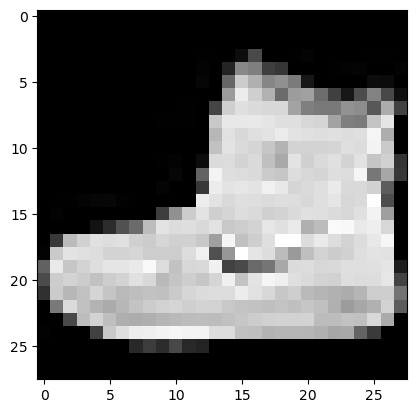

In [160]:
# Current Image
plt.imshow(image.squeeze(), cmap='gray')

In [161]:
rand_image_tensor = torch.randn(size=(1, 28, 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
# Remember that we need to have the image as [batch, channel, height, width]
# We can add an extra dimension

# model_2(rand_image_tensor.unsqueeze(dim=0).to(device))

# The code outputted from the forward pass print statements
# torch.Size([1, 10, 14, 14]) This shape is the output of the first conv block
# torch.Size([1, 10, 7, 7]) This shape is the output of the second conv block

Output shape of Conv Block 1: torch.Size([1, 10, 14, 14])
Output shape of Conv Block 2: torch.Size([1, 10, 7, 7])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x490 and 0x10)

In [163]:
# Fix the input into our classifier 
# Create a convolutional neural network 
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # When we flatten our [1, 10, 7, 7] its really 10*7*7, hidden units is defined as 10 when we instatiate
            # It's because each layer of our network compresses and changes the shape of our input data.
            
            # The input should be hidden_units*7*7
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        print(f"Output shape of Conv Block 1: {x.shape}")
        x = self.block_2(x)
        print(f"Output shape of Conv Block 2: {x.shape}")
        x = self.classifier(x)
        print(f"Output shape of Classifier: {x.shape}")
        return x


In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
model_2(rand_image_tensor.unsqueeze(0).to(device))

Output shape of Conv Block 1: torch.Size([1, 10, 14, 14])
Output shape of Conv Block 2: torch.Size([1, 10, 7, 7])
Output shape of Classifier: torch.Size([1, 10])


tensor([[ 0.0424, -0.0839,  0.0839, -0.0463,  0.0053,  0.0437,  0.0025,  0.0108,
         -0.0158, -0.0177]], device='cuda:0', grad_fn=<AddmmBackward0>)

Just like that it works now!

#### 7.3 Setup a loss function and Optimizer for model_2